# Quick calibration experiments: gparis, Shanghai, YJMOB

This session ran three short, targeted calibration experiments (2-4 extra
config rounds each) against the "full" ablation-matrix baseline for each
dataset, each targeting a different metric family:

- **Paris (gparis)**: lower $\Delta r$ (jump lengths) and $r_g$ (radius of
  gyration) Wasserstein distance.
- **Shanghai**: lower the 4 social-network Wasserstein metrics (degree,
  clustering coefficient, edge persistence, topological overlap).
- **YJMOB**: lower Vf (visits-per-user Wasserstein distance).

Each plot below shows every tracked metric's Wasserstein distance across
the rounds actually run, **up to and including the round adopted as the
best result**, normalized to its own baseline value (baseline = 1.0, lower
is better for every metric here). The metric(s) this round's experiment
targeted are drawn **solid and bold**; every other tracked metric is drawn
**dashed and faint**, so a metric family moving as a side effect (intended
or not) is still visible without competing visually with the target.

All numbers are loaded directly from `data/ablation_logs/*_report.json` --
nothing here is hardcoded.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parents[1]
LOG_DIR = REPO_ROOT / "data" / "ablation_logs"

CORE_METRIC_LABELS = {
    "dr": "$\\Delta r$",
    "rg": "$r_g$",
    "td": "TD",
    "dt": "DT",
    "vf": "Vf",
}
NETWORK_METRIC_LABELS = {
    "degree": "degree",
    "clustering_coefficient": "clustering coef.",
    "edge_persistence": "edge persistence",
    "topological_overlap": "topological overlap",
}
METRIC_LABELS = {**CORE_METRIC_LABELS, **NETWORK_METRIC_LABELS}

# One consistent color per metric across all three panels.
METRIC_COLORS = {
    "dr": "tab:blue",
    "rg": "tab:green",
    "td": "tab:orange",
    "dt": "tab:red",
    "vf": "tab:purple",
    "degree": "tab:brown",
    "clustering_coefficient": "tab:pink",
    "edge_persistence": "tab:olive",
    "topological_overlap": "tab:cyan",
}

In [2]:
def load_core_metrics(tag: str) -> dict[str, float]:
    """Wasserstein distances for the 5 core mobility metrics for one run tag
    (e.g. "gparis_full_run1"). dt is converted minutes -> hours, matching
    this repo's existing notebook/paper-table convention."""
    report = json.loads((LOG_DIR / f"{tag}_report.json").read_text())
    w = report["wasserstein"]
    return {
        "dr": w["jump_lengths_km"],
        "rg": w["radius_of_gyration_km"],
        "td": w["trip_duration_min"],
        "dt": w["dwell_time_min"] / 60.0,
        "vf": w["visits_per_user"],
    }


def load_network_metrics(tag: str) -> dict[str, float]:
    """Wasserstein distances for the 4 social-network metrics
    (synthetic_vs_observed) for one run tag."""
    report = json.loads((LOG_DIR / f"{tag}_report.json").read_text())
    nv = report["network_validation"]["synthetic_vs_observed"]["wasserstein"]
    return dict(nv)


def load_round_metrics(tags: list[str], needs_network: bool) -> dict[str, float]:
    """Average metrics over 1+ run tags (baseline rounds have 3 replicate
    runs; tuning rounds have 1)."""
    core_rows = [load_core_metrics(t) for t in tags]
    averaged = {k: sum(r[k] for r in core_rows) / len(core_rows) for k in core_rows[0]}
    if needs_network:
        net_rows = [load_network_metrics(t) for t in tags]
        averaged.update(
            {k: sum(r[k] for r in net_rows) / len(net_rows) for k in net_rows[0]}
        )
    return averaged

## Scenario definitions

`rounds` lists every round actually run for that experiment, in order,
stopping at the round this session recommended adopting (later rounds that
were tried and rejected -- e.g. gparis r3/r4, Shanghai r4 -- are excluded,
since the ask was to plot progress up to the best result, not every
experiment tried). `target_metrics` are the metric(s) that round's
experiment was explicitly trying to improve.

In [3]:
SCENARIOS = {
    "gparis": {
        "title": "Paris (gparis): targeting $\\Delta r$ and $r_g$",
        "needs_network": False,
        "rounds": [
            ("baseline", ["gparis_full_run1", "gparis_full_run2", "gparis_full_run3"]),
            ("r1", ["gparis_improve_spatial_r1_run1"]),
            ("r2 (adopted)", ["gparis_improve_spatial_r2_run1"]),
        ],
        "target_metrics": ["dr", "rg"],
    },
    "shanghai": {
        "title": "Shanghai: targeting the 4 social-network metrics",
        "needs_network": True,
        "rounds": [
            ("baseline", ["shanghai_full_run1", "shanghai_full_run2", "shanghai_full_run3"]),
            ("r1", ["shanghai_improve_social_r1_run1"]),
            ("r2", ["shanghai_improve_social_r2_run1"]),
            ("r3 (adopted)", ["shanghai_improve_social_r3_run1"]),
        ],
        "target_metrics": ["degree", "clustering_coefficient", "edge_persistence", "topological_overlap"],
    },
    "yjmob": {
        "title": "YJMOB: targeting Vf",
        "needs_network": False,
        "rounds": [
            ("baseline", ["yjmob_full_run1", "yjmob_full_run2", "yjmob_full_run3"]),
            ("r1", ["yjmob_improve_vf_r1_run1"]),
            ("r2", ["yjmob_improve_vf_r2_run1"]),
            ("r3 (adopted)", ["yjmob_improve_vf_r3_run1"]),
        ],
        "target_metrics": ["vf"],
    },
}

# tag -> {metric: value}, one row per round, in round order.
for scenario in SCENARIOS.values():
    scenario["data"] = [
        load_round_metrics(tags, scenario["needs_network"]) for _, tags in scenario["rounds"]
    ]
    scenario["labels"] = [label for label, _ in scenario["rounds"]]

## Plots: Wasserstein distance relative to baseline, per round

Each metric is divided by its own baseline value, so every line starts at
**1.0**; a line dropping below 1.0 is an improvement (lower Wasserstein
distance = closer synthetic-vs-observed match), and above 1.0 is a
regression. This lets metrics in very different native units (km, minutes,
raw visit counts, unbounded degree) share one axis honestly.

One standalone, title-free figure per scenario (paper-ready -- a caption
belongs in the paper text, not baked into the image), each including every
tracked metric for that scenario, saved as its own PDF.

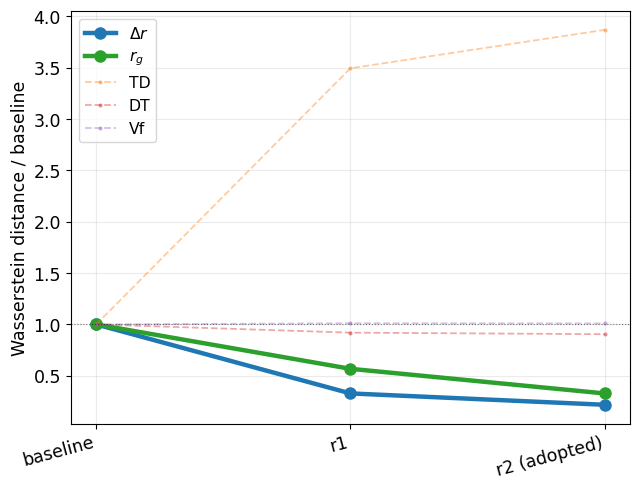

gparis: 5 metrics plotted -> outputs/gparis_progress.pdf
  target: ['dr', 'rg']
  other:  ['dt', 'td', 'vf']


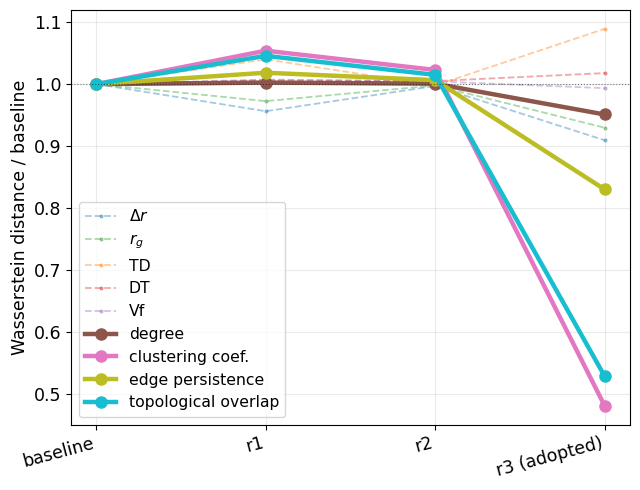

shanghai: 9 metrics plotted -> outputs/shanghai_progress.pdf
  target: ['clustering_coefficient', 'degree', 'edge_persistence', 'topological_overlap']
  other:  ['dr', 'dt', 'rg', 'td', 'vf']


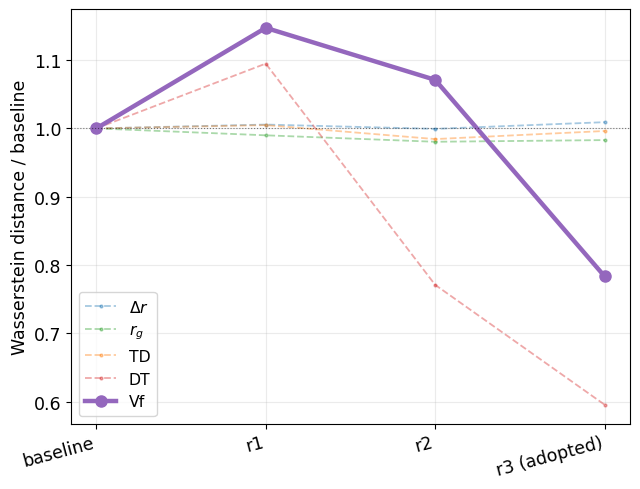

yjmob: 5 metrics plotted -> outputs/yjmob_progress.pdf
  target: ['vf']
  other:  ['dr', 'dt', 'rg', 'td']


In [4]:
Path("outputs").mkdir(exist_ok=True)

FILENAMES = {
    "gparis": "outputs/gparis_progress.pdf",
    "shanghai": "outputs/shanghai_progress.pdf",
    "yjmob": "outputs/yjmob_progress.pdf",
}

for name, scenario in SCENARIOS.items():
    rows = scenario["data"]
    labels = scenario["labels"]
    baseline = rows[0]
    x = range(len(rows))
    target_metrics = set(scenario["target_metrics"])
    all_metrics = list(rows[0].keys())
    assert set(all_metrics) == set(METRIC_COLORS) & set(all_metrics)  # sanity: every metric has a color/label

    fig, ax = plt.subplots(figsize=(6.5, 5))

    for metric in all_metrics:
        y = [row[metric] / baseline[metric] for row in rows]
        is_target = metric in target_metrics
        ax.plot(
            x,
            y,
            label=METRIC_LABELS[metric],
            color=METRIC_COLORS[metric],
            linestyle="-" if is_target else "--",
            linewidth=3.2 if is_target else 1.3,
            alpha=1.0 if is_target else 0.4,
            marker="o" if is_target else ".",
            markersize=8 if is_target else 4,
        )

    ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":", alpha=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("Wasserstein distance / baseline", fontsize=12.5)
    ax.tick_params(axis="both", which="major", labelsize=12.5)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=11.25, loc="best")
    fig.tight_layout()

    fig.savefig(FILENAMES[name])
    fig.savefig(FILENAMES[name].replace(".pdf", ".png"), dpi=150)
    plt.show()

    print(f"{name}: {len(all_metrics)} metrics plotted -> {FILENAMES[name]}")
    print(f"  target: {sorted(target_metrics)}")
    print(f"  other:  {sorted(set(all_metrics) - target_metrics)}")